<a href="https://colab.research.google.com/github/MatheusPimentaMartini/SERS-FIAP-2026-1CCPG/blob/main/aula_apis_energia_renovavel_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [ ]:
import json
import urllib.parse
import urllib.request
import csv

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [ ]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=30) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [ ]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


In [ ]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

UFV: 1200 linhas recebidas
EOL: 1200 linhas recebidas
UHE: 221 linhas recebidas
PCH: 537 linhas recebidas
CGH: 718 linhas recebidas
Total de linhas recebidas: 3876


### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [ ]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

Linhas válidas: 3876
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [ ]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

Salvo: aneel_classificacao_orange.csv


### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Para classificação: KNH, Regressão Logistica, Random Forest
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Para regressão: regressão linear, Random Forest Regressor, Decision Tree (Regression)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# Para classificação
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# Para regressão
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import classification_report

In [ ]:
# Criação do dataframe
df_aneel = pd.read_csv('/content/aneel_classificacao_orange.csv')
df_aneel.head(20)


,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar
5,404.80,-12.945833,-38.417778,Solar
6,1082.00,-22.815833,-47.059167,Solar
7,1.70,-27.447981,-48.501745,Solar
8,1.04,-22.172160,-47.337620,Solar
9,30.87,-2.474278,-43.574217,Solar


In [ ]:
df_aneel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3876 entries, 0 to 3875
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   potencia_kw  3876 non-null   float64
 1   latitude     3876 non-null   float64
 2   longitude    3876 non-null   float64
 3   fonte        3876 non-null   object 
dtypes: float64(3), object(1)
memory usage: 121.3+ KB


In [ ]:
df_aneel['fonte'].unique()

array(['Solar', 'Eólica', 'Hidráulica'], dtype=object)

In [ ]:
df_aneel['fonte'].value_counts()

,count
fonte,
Hidráulica,1476
Solar,1200
Eólica,1200


In [ ]:
df_aneel.isnull().sum()

,0
potencia_kw,0
latitude,0
longitude,0
fonte,0


In [ ]:
X = df_aneel[['potencia_kw', 'latitude', 'longitude']]
y = df_aneel['fonte']

# Divisão estratificada: 80% treino e 20% teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Exibindo as proporções para verificar a estratificação
print("Proporção no conjunto original:\n", y.value_counts(normalize=True))
print("\nProporção no conjunto de treino:\n", y_treino.value_counts(normalize=True))
print("\nProporção no conjunto de teste:\n", y_teste.value_counts(normalize=True))

Proporção no conjunto original:
 fonte
Hidráulica    0.380805
Solar         0.309598
Eólica        0.309598
Name: proportion, dtype: float64

Proporção no conjunto de treino:
 fonte
Hidráulica    0.380645
Solar         0.309677
Eólica        0.309677
Name: proportion, dtype: float64

Proporção no conjunto de teste:
 fonte
Hidráulica    0.381443
Solar         0.309278
Eólica        0.309278
Name: proportion, dtype: float64


In [ ]:
# Classificação diferente
modelo_knn = KNeighborsClassifier()
modelo_reg_log = LogisticRegression()
modelo_rf = RandomForestClassifier()



In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Treinamento
modelo_knn.fit(X_treino, y_treino)


KNeighborsClassifier()

In [ ]:
modelo_reg_log.fit(X_treino, y_treino)


LogisticRegression()

In [ ]:
modelo_rf.fit(X_treino, y_treino)

RandomForestClassifier()

In [ ]:
# Gerando previsões
y_pred_knn = modelo_knn.predict(X_teste)
y_pred_reg_log = modelo_reg_log.predict(X_teste)
y_pred_rf = modelo_rf.predict(X_teste)

In [ ]:
y_pred_knn[:50]

array(['Hidráulica', 'Solar', 'Eólica', 'Hidráulica', 'Hidráulica',
       'Solar', 'Hidráulica', 'Hidráulica', 'Hidráulica', 'Hidráulica',
       'Hidráulica', 'Hidráulica', 'Solar', 'Eólica', 'Eólica', 'Solar',
       'Hidráulica', 'Solar', 'Eólica', 'Eólica', 'Eólica', 'Hidráulica',
       'Solar', 'Eólica', 'Eólica', 'Eólica', 'Solar', 'Eólica', 'Solar',
       'Eólica', 'Eólica', 'Solar', 'Eólica', 'Solar', 'Eólica',
       'Hidráulica', 'Eólica', 'Hidráulica', 'Hidráulica', 'Eólica',
       'Solar', 'Solar', 'Solar', 'Eólica', 'Solar', 'Solar', 'Eólica',
       'Eólica', 'Solar', 'Hidráulica'], dtype=object)

In [ ]:
# avaliando (somente a acuracia)
print(f'Acurácia do KNN: {accuracy_score(y_teste, y_pred_knn)}')
print(f'Acurácia da Regressão Logística: {accuracy_score(y_teste, y_pred_reg_log)}')
print(f'Acurácia do Random Forest: {accuracy_score(y_teste, y_pred_rf)}')

Acurácia do KNN: 0.8685567010309279
Acurácia da Regressão Logística: 0.7242268041237113
Acurácia do Random Forest: 0.9768041237113402


In [ ]:
# Comparação
cr_rl = classification_report(y_teste, y_pred_reg_log)
cr_rl

'              precision    recall  f1-score   support\n\n      Eólica       0.68      0.65      0.66       240\n  Hidráulica       0.78      0.79      0.79       296\n       Solar       0.70      0.71      0.71       240\n\n    accuracy                           0.72       776\n   macro avg       0.72      0.72      0.72       776\nweighted avg       0.72      0.72      0.72       776\n'

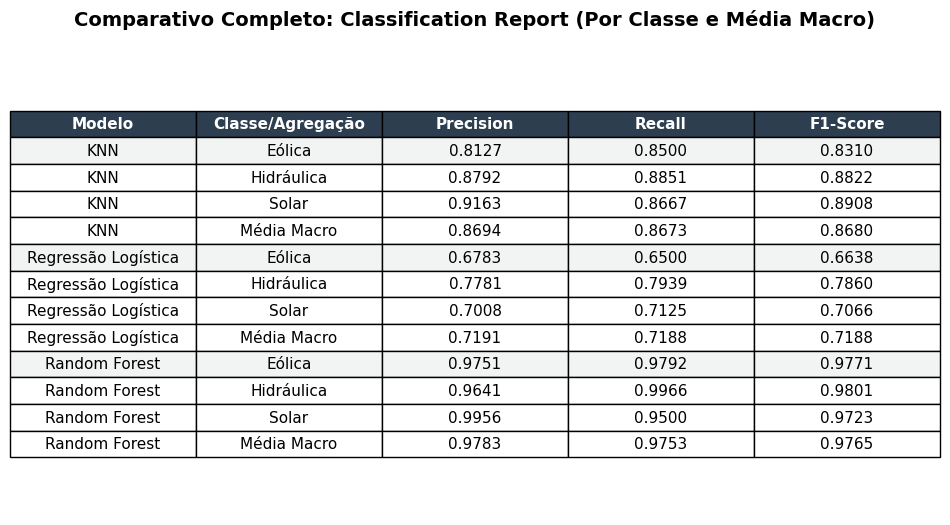

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report

# 1. Gerar relatórios completos de classificação para cada modelo
report_knn = classification_report(y_teste, y_pred_knn, output_dict=True)
report_rl = classification_report(y_teste, y_pred_reg_log, output_dict=True)
report_rf = classification_report(y_teste, y_pred_rf, output_dict=True)

# 2. Estruturar os dados para construir uma única tabela comparativa
classes = ['Eólica', 'Hidráulica', 'Solar', 'macro avg']
modelos = ['KNN', 'Regressão Logística', 'Random Forest']

# Vamos criar linhas no formato: (Modelo, Classe, Precision, Recall, F1-Score)
linhas_tabela = []

for nome_modelo, report in [('KNN', report_knn), ('Regressão Logística', report_rl), ('Random Forest', report_rf)]:
    for classe in classes:
        if classe in report:
            linhas_tabela.append([
                nome_modelo,
                'Média Macro' if classe == 'macro avg' else classe,
                f"{report[classe]['precision']:.4f}",
                f"{report[classe]['recall']:.4f}",
                f"{report[classe]['f1-score']:.4f}"
            ])

# Criar DataFrame para plotar
df_report_comp = pd.DataFrame(linhas_tabela, columns=['Modelo', 'Classe/Agregação', 'Precision', 'Recall', 'F1-Score'])

# 3. Desenhar a tabela utilizando matplotlib
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
ax.axis('tight')

tabela_plot = ax.table(
    cellText=df_report_comp.values,
    colLabels=df_report_comp.columns,
    cellLoc='center',
    loc='center'
)

# Estilização básica da tabela gráfica
tabela_plot.auto_set_font_size(False)
tabela_plot.set_fontsize(11)
tabela_plot.scale(1.2, 1.6)

# Destacar cabeçalhos
for (row, col), cell in tabela_plot.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2c3e50')
    elif row in [1, 5, 9]: # Linhas do KNN, RL e RF iniciais para organização
        cell.set_facecolor('#f2f4f4')

plt.title('Comparativo Completo: Classification Report (Por Classe e Média Macro)', fontsize=14, pad=20, weight='bold')
plt.show()

# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [ ]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [ ]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [ ]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [ ]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

# Entrega pelo GitHub

Envie **apenas o link do repositório público**. Organize-o com:

- `README.md` contendo objetivo, fontes e período dos dados, instruções para executar o notebook e resumo dos resultados;
- notebook `.ipynb` com a consulta às APIs, sua análise, os **três classificadores e os três regressores**, todos os imports necessários adicionados por você e conclusões em Markdown;
- os dois CSVs gerados (ou instruções completas e testadas para reproduzi-los) e eventuais figuras utilizadas.

Verifique se o notebook roda **na ordem das células** a partir de um ambiente limpo. Não inclua senhas, tokens ou arquivos sem relação com a avaliação. A banca deve conseguir encontrar as seis comparações e as respostas às duas tarefas sem procurar uma agulha no palheiro.

### Fontes

- [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel)
- [ANEEL — recurso e campos usados](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel/resource/11ec447d-698d-4ab8-977f-b424d5deee6a)
- [Open-Meteo — histórico e unidades](https://open-meteo.com/en/docs/historical-weather-api)